<h1 align="left">
  <picture>
    <source media="(prefers-color-scheme: dark)" srcset="https://autonomousvision.github.io/py123d/_static/123D_logo_transparent_white.svg" width="500">
    <source media="(prefers-color-scheme: light)" srcset="https://autonomousvision.github.io/py123d/_static/123D_logo_transparent_black.svg" width="500">
    <img alt="Logo" src="https://autonomousvision.github.io/py123d/_static/123D_logo_transparent_black.svg" width="500">
  </picture>
  <h2 align="left">123D: Visualization Tutorial</h1>
</h1>

In [1]:
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np

from py123d.api import MapAPI, SceneAPI, SceneFilter, get_filtered_scenes

## 3.1 Download Demo Logs

You can download demo logs for 123D as described in the [documentation](https://autonomousvision.github.io/py123d/installation/). After the installation and download, you can start with the tutorial.


## 3.2 Create Scenes by filtering the datasets

As in other tutorials, we first query some scenes fro visualization. 

In [2]:
from py123d.datatypes.sensors.pinhole_camera import CameraID

scene_filter = SceneFilter(
    split_names=None,
    duration_s=7.0,  # No duration means that the scene will include the complete log.
    timestamp_threshold_s=0.0,
    shuffle=True,
    map_api_required=False,  # Only include scenes/logs with an available map API.
    camera_ids=[CameraID.PCAM_F0],
)
scenes = get_filtered_scenes(scene_filter)

dataset_splits = set(scene.log_metadata.split for scene in scenes)
print(f"Found {len(scenes)} scenes from {len(dataset_splits)} datasplits:")
for split in dataset_splits:
    print(f" - {split}")

Found 103 scenes from 1 datasplits:
 - pandaset_train


## 3.3 Matplotlib


### 3.3.1 Plots in 2D

Below, we added some standard plot to visualize an iteration of a scene in birds-eye-view:

In [3]:
from py123d.visualization.matplotlib.plots import add_scene_on_ax

scene: SceneAPI = np.random.choice(scenes)  # type: ignore
map_api: Optional[MapAPI] = scene.get_map_api()

if map_api is not None:
    fig, ax = plt.subplots(figsize=(10, 10))
    add_scene_on_ax(ax, scene, iteration=0, radius=80)
    plt.show()

We can also render an animation of the scene with the `render_scene_animation` function. You can use `mp4` or `gif` formats. The current scene will be saved in `./visualization`.

Rendering 005 as mp4:  70%|███████   | 50/71 [00:05<00:02,  8.48it/s]

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '3000x3000', '-pix_fmt', 'rgba', '-framerate', '20.0', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', PosixPath('visualization/005_4570c657-76c2-59b1-b5dd-17680b9862b0.mp4')]' returned non-zero exit status 255.

Rendering 005 as mp4:  72%|███████▏  | 51/71 [00:06<00:06,  3.11it/s]

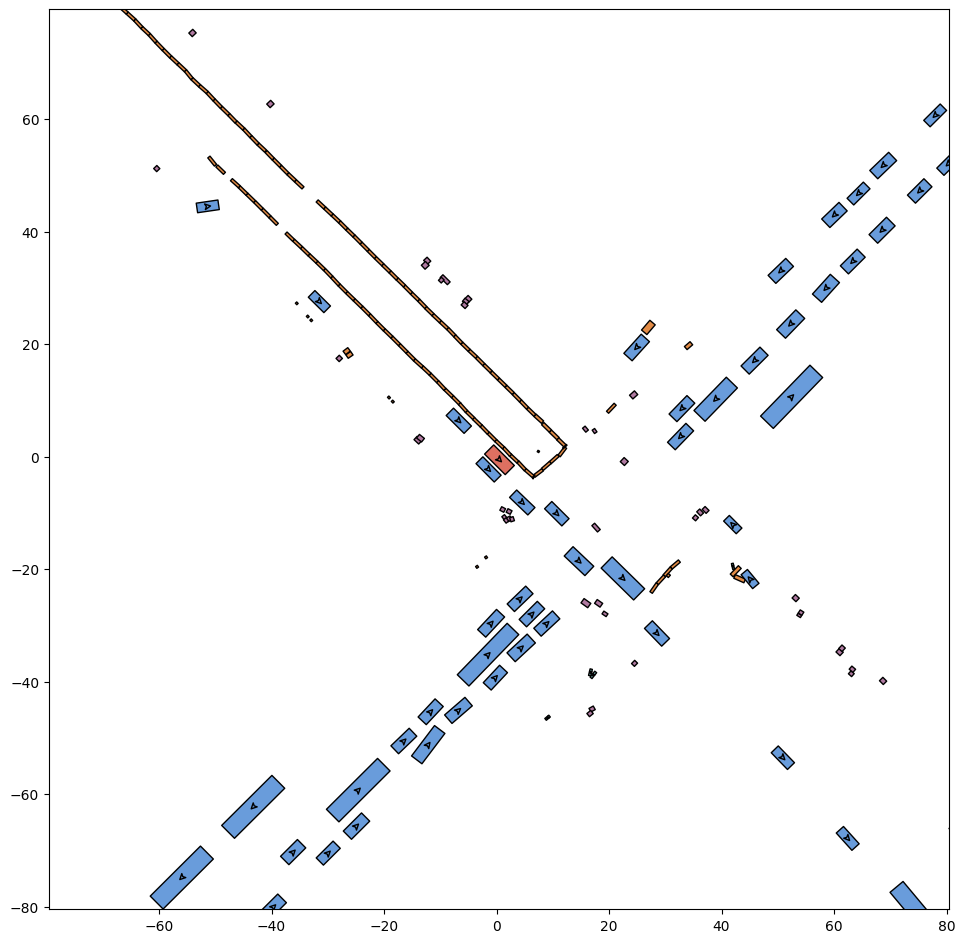

In [4]:
from pathlib import Path

from py123d.visualization.matplotlib.plots import render_scene_animation

save_path = Path("./visualization")
save_path.mkdir(parents=True, exist_ok=True)

fps = 1 / scene.log_metadata.timestep_seconds

render_scene_animation(
    scene=scene,
    output_path=save_path,
    start_idx=0,
    end_idx=None,
    step=1,
    fps=fps * 2,  # Let's speed it up a bit
    dpi=300,
    format="mp4",
    radius=80,
)

### 3.3.2 Plots of Cameras

Below, we have some plot to visualize camera observations with matplotlib. In the simples form, you can retrieve a random camera and add it to a plot:

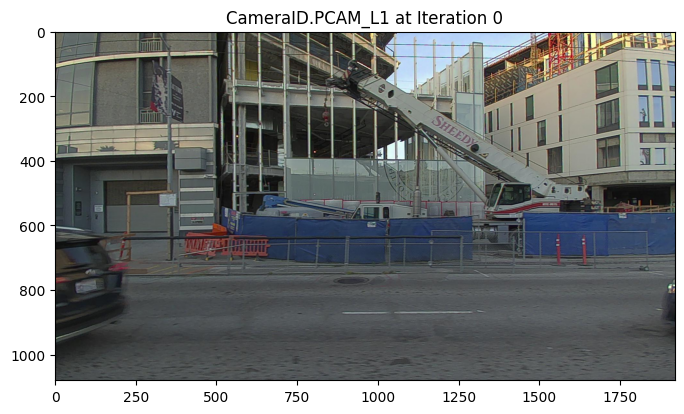

In [ ]:
from py123d.visualization.matplotlib.camera import add_pinhole_camera_ax

iteration = 0
available_camera_ids = scene.available_camera_ids
if len(available_camera_ids) > 1:
    camera_id = np.random.choice(available_camera_ids)  # type: ignore
    camera = scene.get_camera_at_iteration(iteration=iteration, camera_id=camera_id)
    if camera is not None:
        fig, ax = plt.subplots(figsize=(8, 6))
        add_pinhole_camera_ax(ax, camera)
        ax.set_title(f"{camera_id} at Iteration {iteration}")
        plt.show()

You can also visualize the bounding boxes in overlaid in the image with:

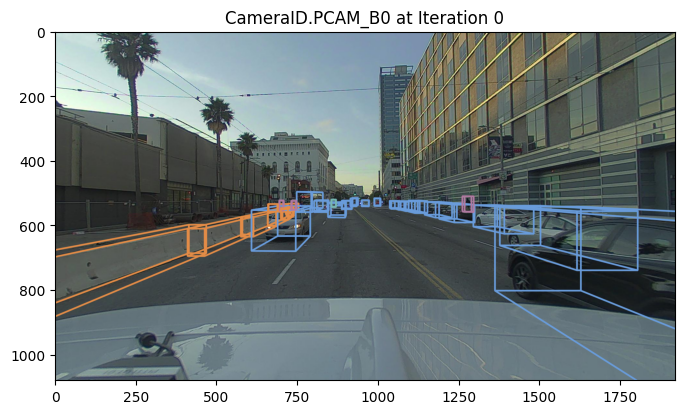

In [ ]:
from py123d.visualization.matplotlib.camera import add_box_detections_to_camera_ax

iteration = 0
available_camera_ids = scene.available_camera_ids
if len(available_camera_ids) > 1:
    camera_id = np.random.choice(available_camera_ids)  # type: ignore
    camera = scene.get_camera_at_iteration(iteration=iteration, camera_id=camera_id)
    box_detections = scene.get_box_detections_se3_at_iteration(iteration=iteration)
    ego_state = scene.get_ego_state_se3_at_iteration(iteration=iteration)
    if camera is not None and box_detections is not None and ego_state is not None:
        fig, ax = plt.subplots(figsize=(8, 6))
        add_box_detections_to_camera_ax(ax, camera, box_detections, ego_state)
        ax.set_title(f"{camera_id} at Iteration {iteration}")
        plt.show()

The same applies for the Lidar point cloud. Here we add the points to the image of a random camera and Lidar scanner. The color map reflects the distance to the ego vehicle.

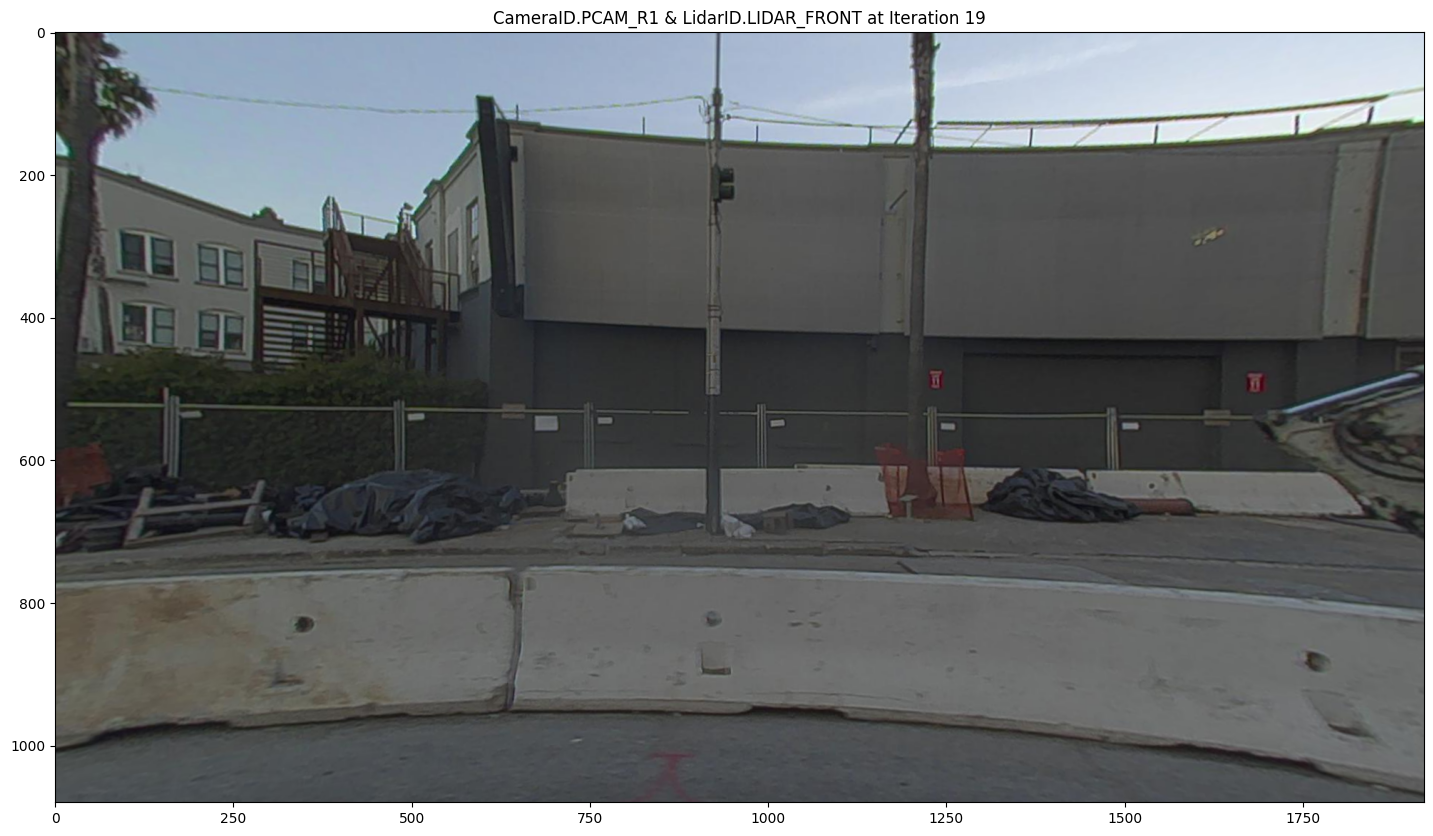

In [ ]:
from py123d.visualization.matplotlib.camera import add_lidar_to_camera_ax

available_camera_ids = scene.available_camera_ids
available_lidar_ids = scene.available_lidar_ids

iteration = 19
if len(available_camera_ids) > 1 and len(available_lidar_ids) > 0:
    camera_id = np.random.choice(available_camera_ids)  # type: ignore
    camera = scene.get_camera_at_iteration(iteration=iteration, camera_id=camera_id)
    lidar_id = np.random.choice(available_lidar_ids)  # type: ignore
    lidar = scene.get_lidar_at_iteration(iteration=iteration, lidar_id=lidar_id)
    ego_state = scene.get_ego_state_se3_at_iteration(iteration=iteration)
    if camera is not None and lidar is not None and ego_state is not None:
        fig, ax = plt.subplots(figsize=(20, 10))
        add_lidar_to_camera_ax(ax, camera, lidar, ego_state)
        ax.set_title(f"{camera_id} & {lidar_id} at Iteration {iteration}")
        plt.show()

## 3.4. Viser

You can visualize a scene in 3D with our viser viewer. 
You can also run viser with:
```sh
py123d-viser scene_filter=...
```
By default, you can open viewer via: [`http://localhost:8080`](http://localhost:8080 )

Check out the [viser documentation](https://viser.studio/main/) for further information.

In [ ]:
from py123d.visualization.viser.viser_viewer import ViserViewer

ViserViewer(scenes)

╭──────────────── viser ────────────────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

Time to get lidar data from scene: 22.48 ms


(viser) Connection opened (0, 1 total), 62 persistent messages

KeyboardInterrupt: 